In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
base_path = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"

In [6]:
covid_folder = os.path.join(base_path, "COVID", "images")

sample_image = os.listdir(covid_folder)[0]

img_path = os.path.join(covid_folder, sample_image)

image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

print(image.shape)

(299, 299)


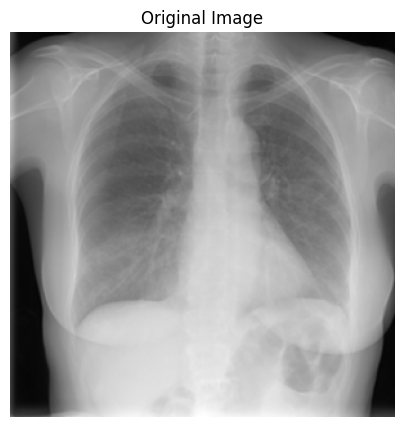

In [7]:
plt.figure(figsize=(5,5))
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [8]:
resized_image = cv2.resize(image, (224,224))

print(resized_image.shape)

(224, 224)


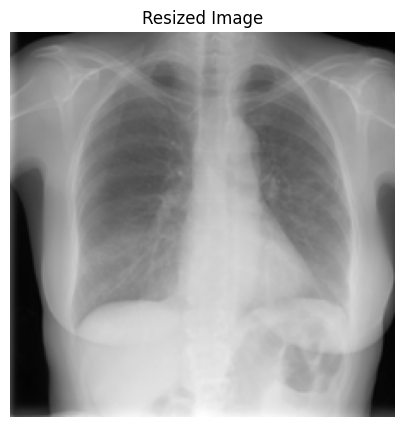

In [9]:
plt.figure(figsize=(5,5))
plt.imshow(resized_image, cmap="gray")
plt.title("Resized Image")
plt.axis("off")
plt.show()

In [10]:
normalized_image = resized_image / 255.0

print("Minimum:", normalized_image.min())
print("Maximum:", normalized_image.max())

Minimum: 0.011764705882352941
Maximum: 0.9882352941176471


In [11]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

clahe_image = clahe.apply(resized_image)

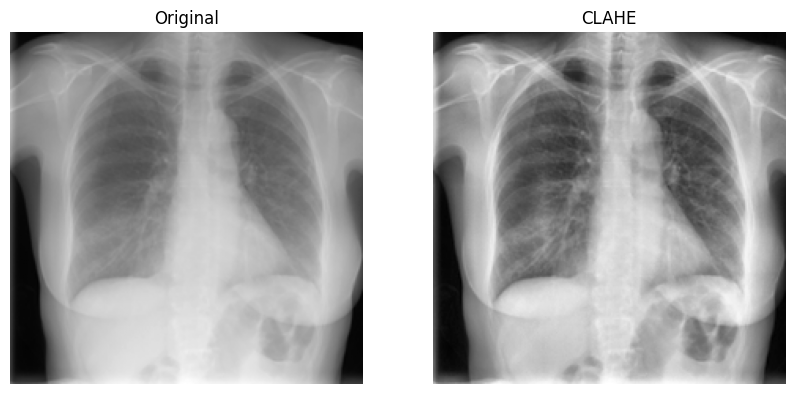

In [12]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(resized_image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clahe_image, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.show()

In [13]:
def preprocess_image(img_path):
    
    image = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    image = cv2.resize(
        image,
        (224,224)
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    image = clahe.apply(image)

    image = image / 255.0

    return image

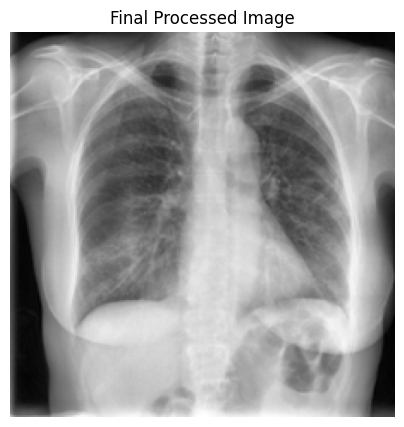

In [14]:
processed = preprocess_image(img_path)

plt.figure(figsize=(5,5))
plt.imshow(processed, cmap="gray")
plt.title("Final Processed Image")
plt.axis("off")
plt.show()